### Alberto Carlos Navarrete Garcia

### import Libraries

In [12]:
import warnings
warnings.simplefilter("ignore")
import matplotlib.pyplot as plt
from sklearn import datasets 
import seaborn as sns
import pandas as pd
import numpy as np

### read the dataset

In [13]:
df = pd.read_csv('iris.csv')

In [14]:
from sklearn.model_selection import train_test_split
y = df['species']
x = df.drop(columns='species')
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state =42)

#### creating the model

In [15]:
from sklearn.neural_network import MLPClassifier
from sklearn import metrics
NN = MLPClassifier(hidden_layer_sizes=5, max_iter=10, activation='relu', learning_rate='constant', learning_rate_init=0.04)
NN.fit(x_train, y_train)


,hidden_layer_sizes,5
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.04
,power_t,0.5
,max_iter,10
,shuffle,True
,random_state,None


### Evaluate the models 

In [ ]:
y_pred = NN.predict(x_test)
metrics.accuracy_score(y_test, y_pred)

0.3333333333333333

Text(50.722222222222214, 0.5, 'Real')

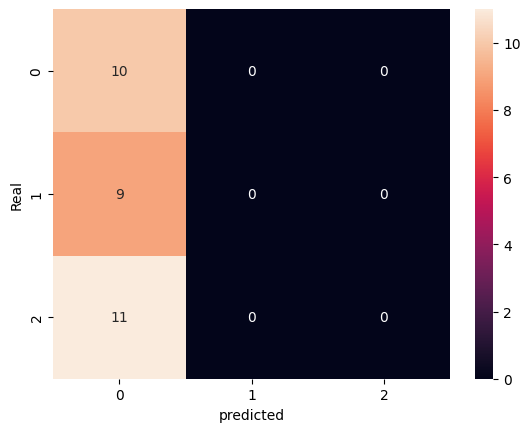

In [ ]:
sns.heatmap(metrics.confusion_matrix(y_test,y_pred), annot=True, fmt = 'd')
plt.xlabel('predicted')
plt.ylabel('Real')

In [19]:
from sklearn.model_selection import  GridSearchCV
param_grid = {
    'hidden_layer_sizes': [(50,), (75,),(100,)],
    'activation': ['relu','tanh'],
    'learning_rate': ['constant', 'adaptive'],
    'alpha': [0.0001, 0.001, 0.01]
}

In [20]:
best_model = GridSearchCV(estimator=NN, param_grid=param_grid,n_jobs=-1)
best_model.fit(x_train, y_train)

,estimator,"MLPClassifier..., max_iter=10)"
,param_grid,"{'activation': ['relu', 'tanh'], 'alpha': [0.0001, 0.001, ...], 'hidden_layer_sizes': [(50,), (75,), ...], 'learning_rate': ['constant', 'adaptive']}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,hidden_layer_sizes,"(50,)"


In [21]:
best_model.best_params_

{'activation': 'relu',
 'alpha': 0.001,
 'hidden_layer_sizes': (50,),
 'learning_rate': 'adaptive'}